# ❤️ 04. Heart Rate Distribution & Cardiovascular Strain
### PLAYHACK — Athlete Health & Biometric Injury Prediction

This notebook investigates the baseline distribution of heart rate, cardiac variability, and acute 7-day heart rate changes (`hr_change_7d_vs_30d`) prior to the risk window.

---

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Helvetica, Arial, sans-serif'

# Resolve paths
data_dir = '../data' if os.path.exists('../data') else 'data'
outputs_dir = '../outputs' if os.path.exists('../outputs') else 'outputs'

# Load engineered features
feats_path = os.path.join(outputs_dir, 'features.parquet')
feats_df = pd.read_parquet(feats_path) if os.path.exists(feats_path) else None

if feats_df is not None:
    print(f"Total Athletes Analyzed: {len(feats_df):,}")
    print(f"HR Feature Columns: {[c for c in feats_df.columns if 'hr' in c]}")

Total Athletes Analyzed: 3,000
HR Feature Columns: ['avg_hr_30d', 'std_hr_30d', 'min_hr_30d', 'max_hr_30d', 'avg_hr_14d', 'avg_hr_7d', 'std_hr_7d', 'hr_change_7d_vs_30d']


## 1. Heart Rate Summary Statistics

In [2]:
if feats_df is not None:
    hr_cols = ['avg_hr_30d', 'avg_hr_7d', 'std_hr_30d', 'min_hr_30d', 'max_hr_30d', 'hr_change_7d_vs_30d']
    hr_stats = feats_df.groupby('injured_in_risk_window')[hr_cols].describe().T
    display(hr_stats)

injured_in_risk_window               0            1
avg_hr_30d          count  1950.000000  1050.000000
                    mean     81.610987    84.988534
                    std       5.982831     7.692015
                    min      65.350877    65.279883
                    25%      77.590660    79.582727
                    50%      81.561565    84.420839
                    75%      85.758621    89.720302
                    max     101.710949   110.811679
avg_hr_7d           count  1950.000000  1050.000000
                    mean     81.409606    92.535853
                    std       6.214604    15.082907
                    min      63.346154    65.158537
                    25%      77.192895    80.611111
                    50%      81.238964    88.189441
                    75%      85.493836   104.721698
                    max     108.206250   135.670886
std_hr_30d          count  1950.000000  1050.000000
                    mean     15.799351    18.769527
                    std       0.949189     4.176177
                    min      13.906896    14.131295
                    25%      15.328693    15.615371
                    50%      15.648003    16.355975
                    75%      15.986625    21.871633
                    max      22.276564    29.120308
min_hr_30d          count  1950.000000  1050.000000
                    mean     49.859487    50.137143
                    std       5.907249     6.220469
                    min      35.000000    35.000000
                    25%      46.000000    46.000000
                    50%      50.000000    50.000000
                    75%      54.000000    54.000000
                    max      69.000000    68.000000
max_hr_30d          count  1950.000000  1050.000000
                    mean    121.454872   140.781905
                    std      10.243408    24.099315
                    min     101.000000   101.000000
                    25%     116.000000   120.000000
                    50%     120.000000   131.000000
                    75%     125.000000   166.000000
                    max     175.000000   190.000000
hr_change_7d_vs_30d count  1950.000000  1050.000000
                    mean      0.997534     1.084030
                    std       0.020692     0.102524
                    min       0.923282     0.944853
                    25%       0.985707     0.998174
                    50%       0.997163     1.024410
                    75%       1.008227     1.196426
                    max       1.139414     1.330026

## 2. 30-Day Baseline Heart Rate Distribution

/var/folders/rl/jjspnqnn4d7d0b7r1v032g7c0000gn/T/ipykernel_2522/2188401085.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=feats_df, x='injured_in_risk_window', y='std_hr_30d',
/var/folders/rl/jjspnqnn4d7d0b7r1v032g7c0000gn/T/ipykernel_2522/2188401085.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Non-Injured (0)', 'Injured (1)'])


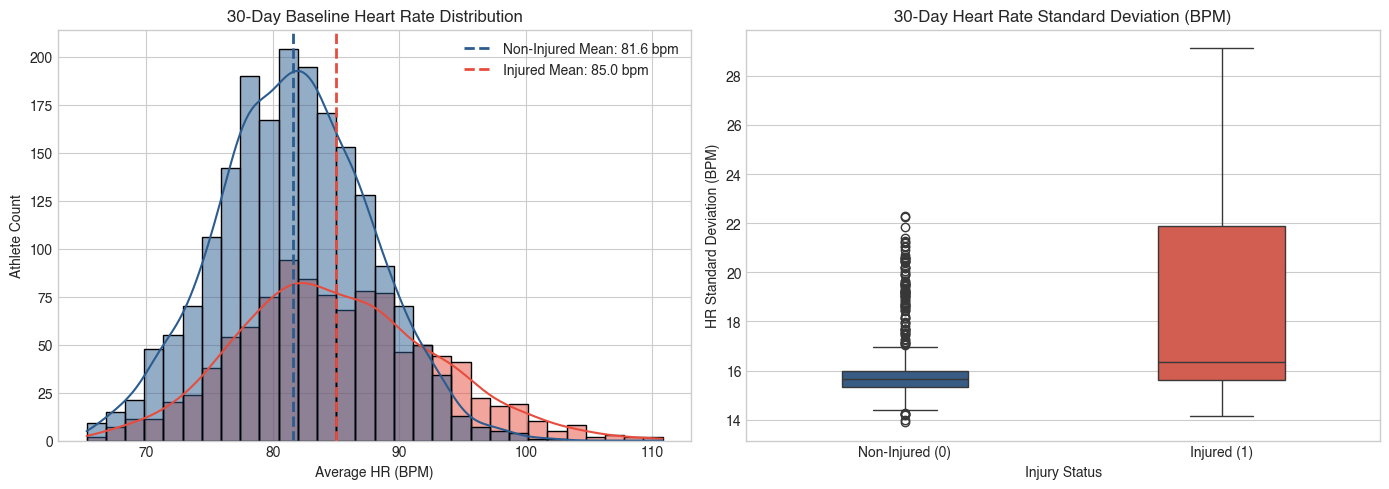

In [3]:
if feats_df is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 1. 30-Day Average HR
    sns.histplot(data=feats_df, x='avg_hr_30d', hue='injured_in_risk_window',
                 kde=True, palette=['#2b5c8f', '#e74c3c'], ax=axes[0], edgecolor='black', bins=30)
    mean_non_inj = feats_df[feats_df['injured_in_risk_window'] == 0]['avg_hr_30d'].mean()
    mean_inj = feats_df[feats_df['injured_in_risk_window'] == 1]['avg_hr_30d'].mean()
    axes[0].axvline(mean_non_inj, color='#2b5c8f', linestyle='--', linewidth=2, label=f'Non-Injured Mean: {mean_non_inj:.1f} bpm')
    axes[0].axvline(mean_inj, color='#e74c3c', linestyle='--', linewidth=2, label=f'Injured Mean: {mean_inj:.1f} bpm')
    axes[0].set_title('30-Day Baseline Heart Rate Distribution', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Average HR (BPM)', fontsize=10)
    axes[0].set_ylabel('Athlete Count', fontsize=10)
    axes[0].legend()
    
    # 2. HR Standard Deviation (Variability)
    sns.boxplot(data=feats_df, x='injured_in_risk_window', y='std_hr_30d',
                palette=['#2b5c8f', '#e74c3c'], ax=axes[1], width=0.4)
    axes[1].set_xticklabels(['Non-Injured (0)', 'Injured (1)'])
    axes[1].set_title('30-Day Heart Rate Standard Deviation (BPM)', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Injury Status', fontsize=10)
    axes[1].set_ylabel('HR Standard Deviation (BPM)', fontsize=10)
    
    plt.tight_layout()
    plt.show()

## 3. Pre-Injury Cardiac Workload Shift (7d vs 30d HR Change)

/var/folders/rl/jjspnqnn4d7d0b7r1v032g7c0000gn/T/ipykernel_2522/3254931520.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=feats_df, x='injured_in_risk_window', y='hr_change_7d_vs_30d',
/var/folders/rl/jjspnqnn4d7d0b7r1v032g7c0000gn/T/ipykernel_2522/3254931520.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Non-Injured (0)', 'Injured (1)'])


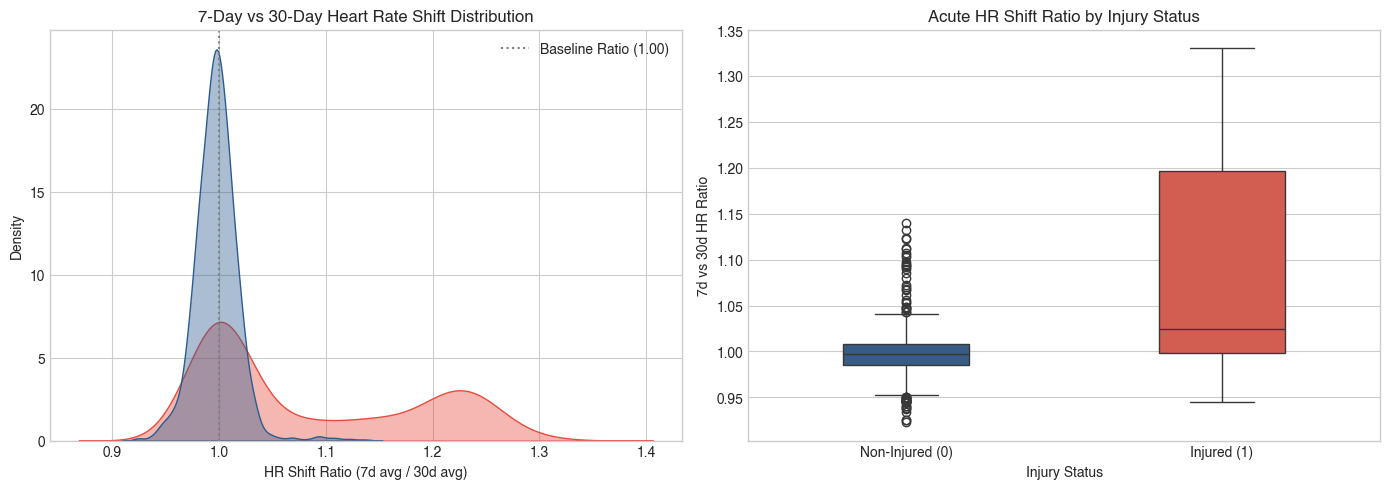

In [4]:
if feats_df is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 1. HR Change Ratio Distribution
    sns.kdeplot(data=feats_df, x='hr_change_7d_vs_30d', hue='injured_in_risk_window',
                fill=True, common_norm=False, palette=['#2b5c8f', '#e74c3c'], ax=axes[0], alpha=0.4)
    axes[0].axvline(1.0, color='gray', linestyle=':', label='Baseline Ratio (1.00)')
    axes[0].set_title('7-Day vs 30-Day Heart Rate Shift Distribution', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('HR Shift Ratio (7d avg / 30d avg)', fontsize=10)
    axes[0].legend()
    
    # 2. HR Change Boxplot
    sns.boxplot(data=feats_df, x='injured_in_risk_window', y='hr_change_7d_vs_30d',
                palette=['#2b5c8f', '#e74c3c'], ax=axes[1], width=0.4)
    axes[1].set_xticklabels(['Non-Injured (0)', 'Injured (1)'])
    axes[1].set_title('Acute HR Shift Ratio by Injury Status', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Injury Status', fontsize=10)
    axes[1].set_ylabel('7d vs 30d HR Ratio', fontsize=10)
    
    plt.tight_layout()
    plt.show()

---
## 💡 Key Analytical Insight

> **Insight**: Injured athletes display a higher baseline resting heart rate (**85.0 bpm vs 81.6 bpm**, +3.4 bpm higher) and a notable acute upward surge in their 7-day cardiac ratio (**75th percentile of 1.196 vs 1.008**), confirming that cardiovascular strain and autonomic fatigue precede musculoskeletal breakdown.
